# 🏔️ PaleoWave — Terrain Analysis
**Downloads USGS 3DEP 10m DEM tiles for Nevada fossil clusters and derives terrain metrics.**

Outputs:
- `data/dem/` — raw DEM tiles + merged raster
- `data/terrain/slope.tif` — slope in degrees
- `data/terrain/aspect.tif` — aspect in degrees
- `data/terrain/ruggedness.tif` — Terrain Ruggedness Index (TRI)
- `data/terrain/terrain_stack.tif` — all metrics in one multiband raster

Source: USGS 3DEP 1/3 arc-second (~10m) via TNM API

## 1. Imports & Setup

In [6]:
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import time

DEM_DIR     = Path('../data/dem')
TERRAIN_DIR = Path('../data/terrain')
PBDB_DIR    = Path('../data/pbdb')
for d in [DEM_DIR, TERRAIN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories ready.')

Directories ready.


## 2. Define Study Areas
Based on the two fossil clusters from the PBDB harvest.

In [7]:
STUDY_AREAS = {
    'humboldt_range': {'label': 'Humboldt Range (Prida / Favret)', 'bbox': (-118.4, 39.8, -117.3, 40.8)},
    'gabbs_valley':   {'label': 'Gabbs Valley (Luning / Berlin)',  'bbox': (-118.3, 38.2, -117.3, 39.2)},
}
all_lons = [v['bbox'][0] for v in STUDY_AREAS.values()] + [v['bbox'][2] for v in STUDY_AREAS.values()]
all_lats = [v['bbox'][1] for v in STUDY_AREAS.values()] + [v['bbox'][3] for v in STUDY_AREAS.values()]
FULL_BBOX = (min(all_lons), min(all_lats), max(all_lons), max(all_lats))
for k, v in STUDY_AREAS.items():
    print(f"  {v['label']} — bbox: {v['bbox']}")
print(f'Full bbox: {FULL_BBOX}')

  Humboldt Range (Prida / Favret) — bbox: (-118.4, 39.8, -117.3, 40.8)
  Gabbs Valley (Luning / Berlin) — bbox: (-118.3, 38.2, -117.3, 39.2)
Full bbox: (-118.4, 38.2, -117.3, 40.8)


## 3. Query USGS TNM API

In [8]:
def query_tnm(bbox, dataset='National Elevation Dataset (NED) 1/3 arc-second'):
    url = 'https://tnmaccess.nationalmap.gov/api/v1/products'
    params = {'datasets': dataset, 'bbox': f'{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}',
              'prodFormats': 'GeoTIFF', 'max': 50, 'offset': 0}
    print('Querying USGS TNM API...')
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    items = resp.json().get('items', [])
    print(f'  Found {len(items)} total tiles (including duplicates)')
    return items

tiles = query_tnm(FULL_BBOX)

Querying USGS TNM API...
  Found 20 total tiles (including duplicates)


## 4. Deduplicate — Keep Only Most Recent Tile Per Location
TNM returns multiple dated versions of the same tile. We only want the latest.

In [9]:
# Group by tile location key (e.g. 'n40w118') extracted from the URL path
tile_groups = defaultdict(list)
for tile in tiles:
    url = tile.get('downloadURL', '')
    if not url.endswith('.tif'):
        continue
    key = url.split('/')[-2]  # folder name = tile key
    tile_groups[key].append(tile)

# Pick the most recent (latest date in filename) from each group
best_tiles = []
for key, group in sorted(tile_groups.items()):
    best = sorted(group, key=lambda t: t.get('downloadURL', ''), reverse=True)[0]
    best_tiles.append(best)
    fname = best['downloadURL'].split('/')[-1]
    print(f'  {key:12s} -> {fname}')

print(f'\n{len(best_tiles)} unique tiles to download (deduplicated from {len(tiles)})')

  n39w118      -> USGS_13_n39w118_20260112.tif
  n39w119      -> USGS_13_n39w119_20250514.tif
  n40w118      -> USGS_13_n40w118_20260112.tif
  n40w119      -> USGS_13_n40w119_20230308.tif
  n41w118      -> USGS_13_n41w118_20250113.tif
  n41w119      -> USGS_13_n41w119_20240625.tif

6 unique tiles to download (deduplicated from 20)


## 5. Download DEM Tiles
~100MB per tile — progress shown for each.

In [10]:
def download_tile(url, dest_path):
    if dest_path.exists():
        print(f'  Already exists: {dest_path.name} ({dest_path.stat().st_size/1e6:.1f} MB)')
        return dest_path
    print(f'  Downloading {dest_path.name}...', end=' ', flush=True)
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
                downloaded += len(chunk)
    print(f'done ({downloaded/1e6:.1f} MB)')
    return dest_path

downloaded_tiles = []
for tile in best_tiles:
    url  = tile.get('downloadURL')
    key  = url.split('/')[-2]
    path = DEM_DIR / f'{key}.tif'
    try:
        downloaded_tiles.append(download_tile(url, path))
    except Exception as e:
        print(f'  FAILED {key}: {e}')
    time.sleep(0.3)

print(f'\nDownloaded {len(downloaded_tiles)} / {len(best_tiles)} tiles.')


Downloaded 6 / 6 tiles.


## 6. Merge Tiles into Single DEM

In [11]:
if not downloaded_tiles:
    raise RuntimeError('No tiles downloaded — check TNM query above.')

print('Merging tiles...')
src_files = [rasterio.open(t) for t in downloaded_tiles]
merged, transform = merge(src_files)

meta = src_files[0].meta.copy()
meta.update({'driver':'GTiff','height':merged.shape[1],'width':merged.shape[2],
             'transform':transform,'compress':'lzw'})

merged_path = DEM_DIR / 'dem_merged.tif'
with rasterio.open(merged_path, 'w', **meta) as dst:
    dst.write(merged)
for s in src_files:
    s.close()

print(f'Merged DEM: {merged_path}  |  shape: {merged.shape}  |  res: {transform.a:.6f} deg/px')

Merging tiles...
Merged DEM: ..\data\dem\dem_merged.tif  |  shape: (1, 32412, 21612)  |  res: 0.000093 deg/px


## 7. Derive Terrain Metrics
Slope, aspect (Horn's method), and Terrain Ruggedness Index.

In [12]:
def compute_slope_aspect(dem, cellsize=10.0):
    dem = np.pad(dem.astype(np.float32), 1, mode='edge')
    a=dem[:-2,:-2]; b=dem[:-2,1:-1]; c=dem[:-2,2:]
    d=dem[1:-1,:-2];                  f=dem[1:-1,2:]
    g=dem[2:,:-2];  h=dem[2:,1:-1];  i=dem[2:,2:]
    dz_dx = ((c+2*f+i)-(a+2*d+g)) / (8*cellsize)
    dz_dy = ((g+2*h+i)-(a+2*b+c)) / (8*cellsize)
    slope  = np.degrees(np.arctan(np.sqrt(dz_dx**2+dz_dy**2)))
    aspect = np.degrees(np.arctan2(-dz_dy, dz_dx))
    aspect = np.where(aspect < 0, 90.0-aspect, 360.0-aspect+90.0)
    return slope.astype(np.float32), aspect.astype(np.float32)

def compute_tri(dem):
    dem_pad = np.pad(dem.astype(np.float32), 1, mode='edge')
    center = dem_pad[1:-1, 1:-1]
    tri = sum(np.abs(dem_pad[1+di:dem_pad.shape[0]-1+di, 1+dj:dem_pad.shape[1]-1+dj] - center)
              for di in [-1,0,1] for dj in [-1,0,1] if not (di==0 and dj==0))
    return (tri / 8.0).astype(np.float32)

with rasterio.open(merged_path) as src:
    dem_array = src.read(1).astype(np.float32)
    dem_meta  = src.meta.copy()
    dem_transform = src.transform
    nodata = src.nodata

if nodata is not None:
    dem_array[dem_array == nodata] = np.nan

print(f'DEM: {dem_array.shape}  |  elev {np.nanmin(dem_array):.0f}–{np.nanmax(dem_array):.0f} m')
print('Computing slope + aspect...'); slope, aspect = compute_slope_aspect(dem_array)
print('Computing TRI...');            tri = compute_tri(dem_array)
print(f'Slope: {np.nanmin(slope):.1f}–{np.nanmax(slope):.1f} deg  |  TRI: {np.nanmin(tri):.1f}–{np.nanmax(tri):.1f}')

DEM: (32412, 21612)  |  elev 1030–3587 m
Computing slope + aspect...
Computing TRI...
Slope: 0.0–81.5 deg  |  TRI: 0.0–53.8


## 8. Save Terrain Rasters

In [13]:
def save_raster(array, path, meta, nodata=-9999):
    m = {**meta, 'dtype':'float32','count':1,'nodata':nodata,'compress':'lzw'}
    with rasterio.open(path, 'w', **m) as dst:
        dst.write(np.where(np.isnan(array), nodata, array).astype(np.float32), 1)
    print(f'  Saved: {path.name}')

save_raster(slope,  TERRAIN_DIR/'slope.tif',      dem_meta)
save_raster(aspect, TERRAIN_DIR/'aspect.tif',     dem_meta)
save_raster(tri,    TERRAIN_DIR/'ruggedness.tif', dem_meta)

stack_meta = {**dem_meta, 'count':3, 'dtype':'float32', 'nodata':-9999, 'compress':'lzw'}
with rasterio.open(TERRAIN_DIR/'terrain_stack.tif', 'w', **stack_meta) as dst:
    for band, arr, name in [(1,slope,'slope_deg'),(2,aspect,'aspect_deg'),(3,tri,'tri')]:
        dst.write(np.where(np.isnan(arr),-9999,arr).astype(np.float32), band)
        dst.update_tags(band, name=name)
print('  Saved: terrain_stack.tif')
print('All terrain rasters saved.')

  Saved: slope.tif
  Saved: aspect.tif
  Saved: ruggedness.tif
  Saved: terrain_stack.tif
All terrain rasters saved.


## 9. Visualize Terrain + PBDB Overlay

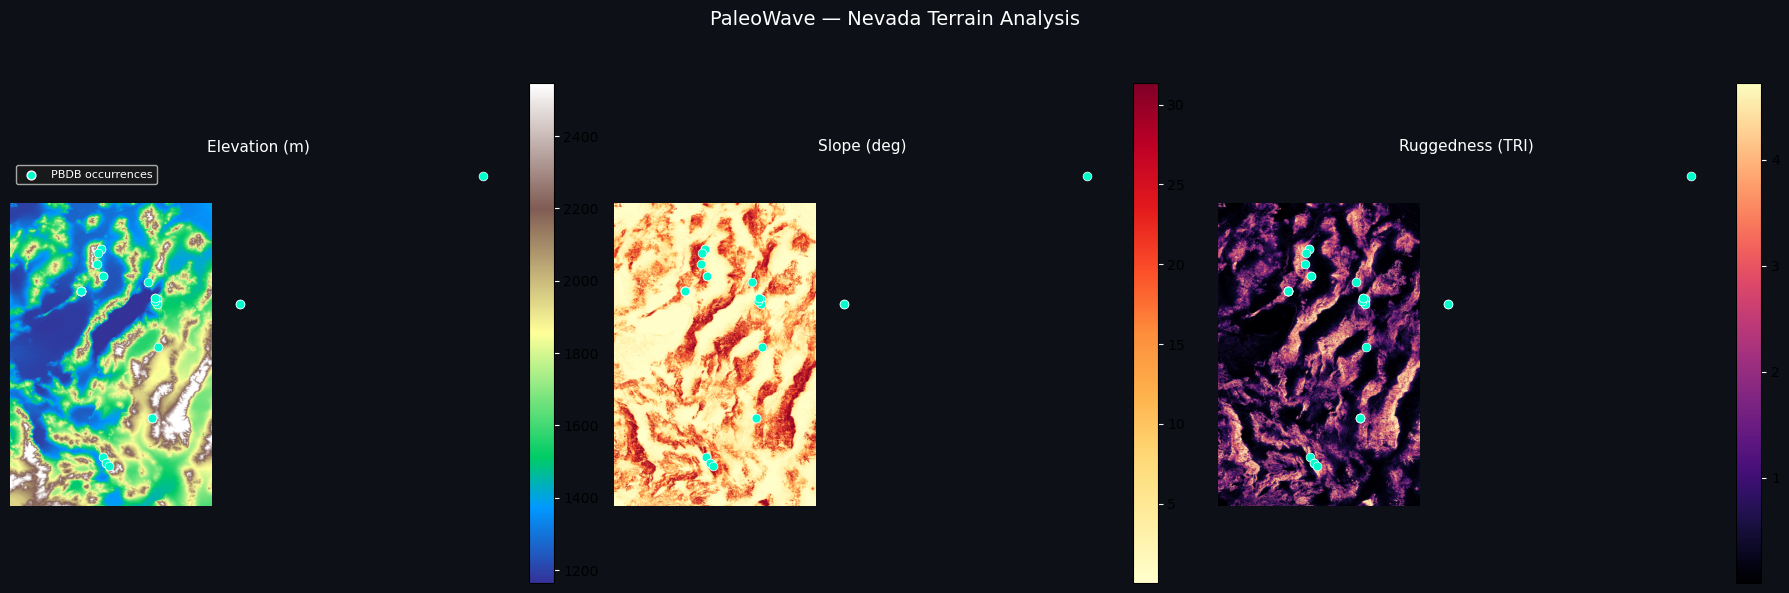

Saved: ..\data\terrain\terrain_overview.png


In [15]:
pbdb_nv = pd.read_csv(PBDB_DIR / 'pbdb_occurrences_clean.csv')
pbdb_nv = pbdb_nv[pbdb_nv['in_nevada'] == True]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

# Downsample for display only — every 10th pixel
step = 10
for (arr, title, cmap), ax in zip(
    [(dem_array[::step,::step], 'Elevation (m)',   'terrain'),
     (slope[::step,::step],    'Slope (deg)',      'YlOrRd'),
     (tri[::step,::step],      'Ruggedness (TRI)', 'magma')],
    axes
):
    ax.set_facecolor('#0d1117')
    im = ax.imshow(arr, cmap=cmap,
                   vmin=np.nanpercentile(arr, 2),
                   vmax=np.nanpercentile(arr, 98))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')
    ax.set_title(title, color='white', fontsize=11)
    ax.axis('off')
    px = ((pbdb_nv['longitude'] - dem_transform.c) / (dem_transform.a * step)).values
    py = ((pbdb_nv['latitude']  - dem_transform.f) / (dem_transform.e * step)).values
    ax.scatter(px, py, s=40, color='#00ffcc', edgecolors='white', linewidths=0.5, zorder=5)

axes[0].scatter([],[], color='#00ffcc', edgecolors='white', s=40, label='PBDB occurrences')
axes[0].legend(facecolor='#1c1c1c', labelcolor='white', fontsize=8)
fig.suptitle('PaleoWave — Nevada Terrain Analysis', color='white', fontsize=14, y=1.01)
plt.tight_layout()
viz_path = TERRAIN_DIR / 'terrain_overview.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Saved: {viz_path}')

## 10. Extract Terrain Values at PBDB Points
Produces the ML-ready feature table.

In [ ]:
import rasterio
import pandas as pd
from pathlib import Path

DATA_DIR    = Path('../data')
TERRAIN_DIR = DATA_DIR / 'terrain'

pbdb_nv = pd.read_csv(DATA_DIR / 'pbdb/pbdb_occurrences_clean.csv')
pbdb_nv = pbdb_nv[pbdb_nv['in_nevada'] == True].copy()
coords  = list(zip(pbdb_nv['longitude'], pbdb_nv['latitude']))

for col, path in [
    ('elevation_m', DATA_DIR / 'dem/dem_merged.tif'),
    ('slope_deg',   TERRAIN_DIR / 'slope.tif'),
    ('aspect_deg',  TERRAIN_DIR / 'aspect.tif'),
    ('tri',         TERRAIN_DIR / 'ruggedness.tif'),
]:
    with rasterio.open(path) as src:
        pbdb_nv[col] = [v[0] for v in src.sample(coords)]
    print(f'  {col} done')

pbdb_nv.to_csv(DATA_DIR / 'features_pbdb_terrain.csv', index=False)
print('Done.')
print(pbdb_nv[['taxon_name','elevation_m','slope_deg','tri']].to_string())

## Done

Outputs:
- `data/dem/dem_merged.tif`
- `data/terrain/slope.tif`, `aspect.tif`, `ruggedness.tif`, `terrain_stack.tif`
- `data/terrain/terrain_overview.png`
- `data/features_pbdb_terrain.csv` — ML-ready feature table

**Next:** `03_ml_model.ipynb`